# Etapa 3 — Construção de Modelo (K-Means Clustering)

## Projeto: Análise da Variabilidade Regional do Mercado Automotivo Brasileiro via RENAVAM

**Objetivo:** Aplicar o algoritmo K-Means para descobrir agrupamentos naturais ("Brasis Automotivos") com base em variáveis socioeconômicas e de composição da frota dos municípios brasileiros.

### Natureza da Técnica Aplicada

O K-Means é um algoritmo de **aprendizado não supervisionado**. Isso implica importantes consequências para a interpretação dos resultados:

- **Não existe variável-alvo (target)** no sentido de regressão ou classificação
- O modelo **não mede poder preditivo** — apenas identifica grupos de observações semelhantes no espaço de features
- Todas as variáveis utilizadas atuam como **features descritivas** que compõem o espaço de clusterização (incluindo `target_perc_diesel` e `target_perc_utilitarios`, cujos nomes foram herdados do dataset original mas, neste contexto, representam apenas variáveis descritivas)
- A análise revela **associações estruturais** entre os perfis municipais, **não relações causais ou preditivas**

### Justificativa da Escolha
O K-Means foi selecionado como primeiro modelo por ser uma técnica exploratória adequada para identificar padrões de agrupamento na estrutura dos dados, sem necessidade de rótulos pré-definidos. Essa abordagem é apropriada como passo inicial antes de modelos supervisionados (Etapa 4), que serão usados para testar hipóteses preditivas.

## 1. Pré-processamento dos Dados

### 1.1. Tratamento de Valores Ausentes (Refinado)

O pipeline ETL foi revisado para tratar NaN **variável por variável**, em vez de aplicar `fillna(0)` global. As decisões foram:

| Variável | Tratamento | Justificativa |
|:---|:---|:---|
| Frota (TOTAL, AUTOMOVEL, etc.) | `fillna(0)` | Ausência no RENAVAM = sem registro = frota zero |
| Infraestrutura DNIT | `fillna(0)` | Ausência no DNIT = sem rodovia federal |
| **PIB e População** | **Mantido NaN** | Ausência real de dados — registros excluídos antes da modelagem |
| Indicadores per capita | `np.where` com NaN se denominador = 0 | Evita divisão por zero artificial |

### 1.2. Estratégia de Limpeza para Clusterização
- Exclusão de municípios com **NaN em features essenciais** (PIB, população, frota)
- Não usamos `replace(0, 1)` em denominadores (corrigido no ETL após feedback)

### 1.3. Seleção de Features para Clusterização
Utilizamos 6 variáveis que descrevem o **perfil socioeconômico** e a **composição da frota** de cada município:

| Feature | Descrição | Papel |
|:---|:---|:---|
| `target_perc_diesel` | % da frota que é diesel | Variável descritiva da composição da frota |
| `target_perc_utilitarios` | % da frota que é utilitários | Variável descritiva da composição da frota |
| `pib_agro_por_habitante` | PIB agropecuário per capita | Variável descritiva da vocação econômica |
| `pib_per_capita` | PIB total per capita | Variável descritiva de riqueza |
| `densidade_demografica` | Habitantes por km² | Variável descritiva de urbanização |
| `presenca_rodovia_federal` | Indicador binário | Variável descritiva de infraestrutura |

**Observação importante:** Nomes como `target_perc_diesel` foram herdados do dataset original. No contexto da clusterização (não supervisionada), essas variáveis funcionam apenas como **features do espaço de agrupamento**, não como variáveis-alvo.

### 1.4. Normalização
O K-Means utiliza distância euclidiana, sendo sensível à escala. Aplicamos `StandardScaler` (média=0, desvio=1) após `log1p` em variáveis com forte assimetria (PIB, densidade).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_theme(style="whitegrid")

# Carregar dataset
df = pd.read_csv('ETL/Dados Tratados/Dados Unificados/dataset_final_modelagem.csv')
print(f"Dataset original: {df.shape[0]} munic\u00edpios")

Dataset original: 5571 municípios


In [2]:
# 1. Seleção de features para clusterização
features_cluster = [
    'target_perc_diesel',
    'target_perc_utilitarios',
    'pib_agro_por_habitante',
    'pib_per_capita',
    'densidade_demografica',
    'presenca_rodovia_federal'
]

# 2. Limpeza: excluir municípios com NaN em qualquer feature essencial
print(f"Dataset original: {df.shape[0]} municípios")
print(f"\nNaN por feature:")
print(df[features_cluster].isna().sum())

df_clean = df.dropna(subset=features_cluster).copy()
n_removidos = df.shape[0] - df_clean.shape[0]
print(f"\nApós exclusão de NaN: {df_clean.shape[0]} municípios (removidos: {n_removidos})")

# 3. Também excluímos municípios sem frota registrada (TOTAL=0)
# pois suas proporções serão zero artificialmente, distorcendo os clusters
df_clean = df_clean[df_clean['TOTAL'] > 0].copy()
print(f"Após exclusão de TOTAL=0: {df_clean.shape[0]} municípios")

# 4. Preparar matriz de features
X = df_clean[features_cluster].copy()

# 5. Log transform em variáveis com assimetria extrema (Etapa 2 confirmou)
for col in ['pib_agro_por_habitante', 'pib_per_capita', 'densidade_demografica']:
    X[col] = np.log1p(X[col])

print(f"\nFeatures selecionadas: {features_cluster}")
print(f"Shape final: {X.shape}")

# 6. Normalização com StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nApós normalização:")
print(f"  Média das features: {X_scaled.mean(axis=0).round(4)}")
print(f"  Desvio das features: {X_scaled.std(axis=0).round(4)}")

Dataset original: 5571 municípios

NaN por feature:
target_perc_diesel          0
target_perc_utilitarios     0
pib_agro_por_habitante      0
pib_per_capita              0
densidade_demografica       0
presenca_rodovia_federal    0
dtype: int64

Após exclusão de NaN: 5571 municípios (removidos: 0)
Após exclusão de TOTAL=0: 5527 municípios

Features selecionadas: ['target_perc_diesel', 'target_perc_utilitarios', 'pib_agro_por_habitante', 'pib_per_capita', 'densidade_demografica', 'presenca_rodovia_federal']
Shape final: (5527, 6)

Após normalização:
  Média das features: [-0.  0.  0. -0.  0. -0.]
  Desvio das features: [1. 1. 1. 1. 1. 1.]


## 2. Determinação do Número Ótimo de Clusters

Antes de rodar o K-Means, precisamos definir o número de clusters (k). Utilizamos dois métodos complementares:

1. **Método do Cotovelo (Elbow Method):** Plota a inércia (soma das distâncias ao centróide) para diferentes valores de k. O "cotovelo" indica o ponto onde adicionar mais clusters traz retornos decrescentes.
2. **Silhouette Score:** Mede quão bem cada ponto se encaixa no seu cluster vs. o cluster vizinho. Varia de -1 (mal classificado) a +1 (bem classificado). Quanto maior, melhor.

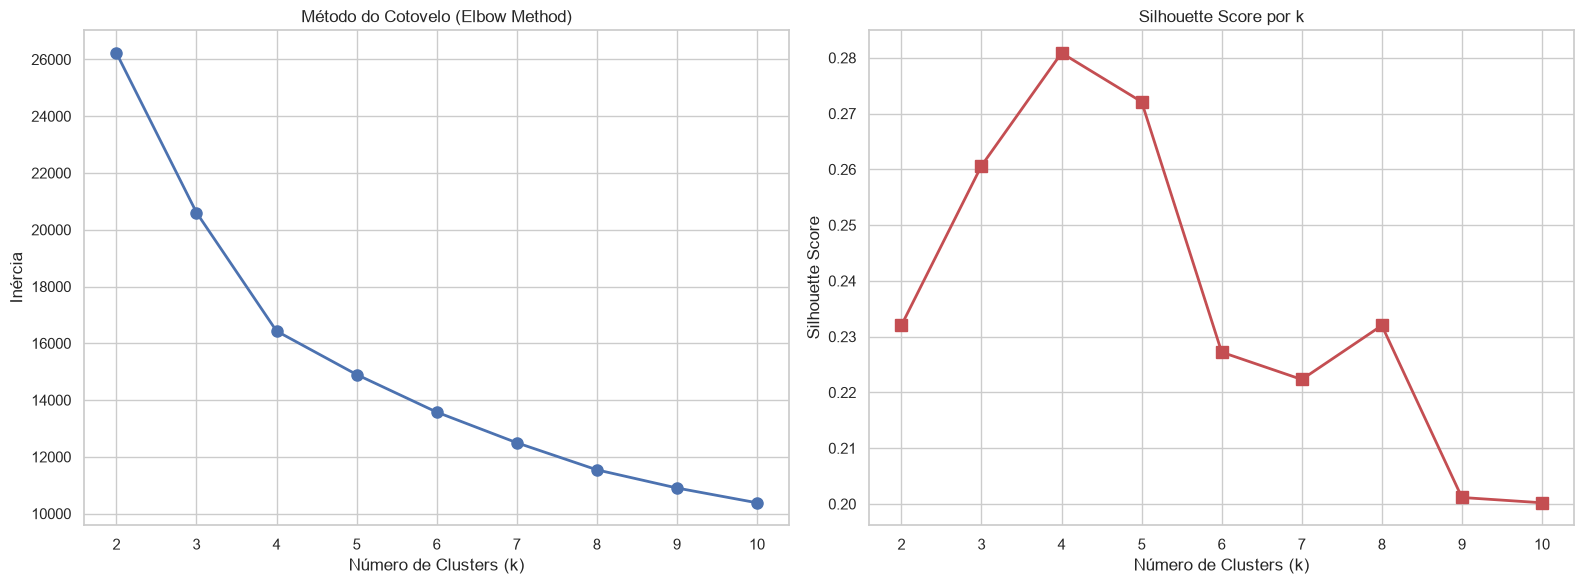


Melhor k pelo Silhouette Score: 4 (score=0.2809)

Todos os scores:
  k=2: Silhouette=0.2320 | Inércia=26227
  k=3: Silhouette=0.2606 | Inércia=20606
  k=4: Silhouette=0.2809 | Inércia=16430 <-- melhor
  k=5: Silhouette=0.2721 | Inércia=14899
  k=6: Silhouette=0.2272 | Inércia=13576
  k=7: Silhouette=0.2223 | Inércia=12497
  k=8: Silhouette=0.2320 | Inércia=11543
  k=9: Silhouette=0.2012 | Inércia=10903
  k=10: Silhouette=0.2002 | Inércia=10382


In [3]:
# Teste de k de 2 a 10
k_range = range(2, 11)
inertias = []
silhouettes = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

# Gr\u00e1ficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Elbow
axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('N\u00famero de Clusters (k)')
axes[0].set_ylabel('In\u00e9rcia')
axes[0].set_title('M\u00e9todo do Cotovelo (Elbow Method)')
axes[0].set_xticks(list(k_range))

# Silhouette
axes[1].plot(k_range, silhouettes, 'rs-', linewidth=2, markersize=8)
axes[1].set_xlabel('N\u00famero de Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score por k')
axes[1].set_xticks(list(k_range))

plt.tight_layout()
plt.show()

# Melhor k pelo Silhouette
best_k = list(k_range)[np.argmax(silhouettes)]
print(f"\nMelhor k pelo Silhouette Score: {best_k} (score={max(silhouettes):.4f})")
print(f"\nTodos os scores:")
for k, s in zip(k_range, silhouettes):
    marker = " <-- melhor" if k == best_k else ""
    print(f"  k={k}: Silhouette={s:.4f} | In\u00e9rcia={inertias[k-2]:.0f}{marker}")

## 3. Treinamento do Modelo K-Means

### Sobre o Algoritmo
O K-Means é um algoritmo de aprendizado não supervisionado que particiona os dados em k grupos, minimizando a variância intra-cluster (inércia). Funciona iterativamente:
1. Inicializa k centróides aleatoriamente
2. Atribui cada ponto ao centróide mais próximo
3. Recalcula os centróides como a média dos pontos do cluster
4. Repete até convergência

**Vantagens:** Eficiente em grandes datasets, interpretável, escalável.
**Limitações:** Sensível à inicialização (mitigado com `n_init=10`), assume clusters esféricos, requer definição prévia de k.

### Parâmetros Escolhidos
- `n_clusters`: definido pelo Silhouette Score
- `random_state=42`: reprodutibilidade
- `n_init=10`: executa 10 inicializações e escolhe a melhor
- `max_iter=300`: limite de iterações para convergência

In [4]:
# Treinar modelo final com o melhor k
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10, max_iter=300)
df_clean['cluster'] = kmeans_final.fit_predict(X_scaled)

print(f"Modelo K-Means treinado com k={best_k}")
print(f"In\u00e9rcia final: {kmeans_final.inertia_:.2f}")
print(f"Itera\u00e7\u00f5es at\u00e9 converg\u00eancia: {kmeans_final.n_iter_}")
print(f"\nDistribui\u00e7\u00e3o dos clusters:")
print(df_clean['cluster'].value_counts().sort_index())
print(f"\nSilhouette Score final: {silhouette_score(X_scaled, df_clean['cluster']):.4f}")

Modelo K-Means treinado com k=4
Inércia final: 16430.20
Iterações até convergência: 14

Distribuição dos clusters:
cluster
0    2689
1    1986
2     741
3     111
Name: count, dtype: int64



Silhouette Score final: 0.2809


## 4. Análise e Interpretação dos Clusters

O objetivo principal é entender **o que define cada cluster** — quais características socioeconômicas e de frota distinguem os grupos de municípios.

In [5]:
# Perfil m\u00e9dio de cada cluster
perfil_medio = df_clean.groupby('cluster')[features_cluster].mean().round(4)
print("PERFIL M\u00c9DIO DE CADA CLUSTER")
print("=" * 80)
print(perfil_medio.T)

# Contar munic\u00edpios e UFs por cluster
print("\n\nDISTRIBUI\u00c7\u00c3O GEOGR\u00c1FICA POR CLUSTER")
print("=" * 80)
for c in sorted(df_clean['cluster'].unique()):
    subset = df_clean[df_clean['cluster'] == c]
    top_ufs = subset['uf'].value_counts().head(5)
    print(f"\nCluster {c} ({len(subset)} munic\u00edpios):")
    print(f"  Popula\u00e7\u00e3o m\u00e9dia: {subset['populacao'].mean():,.0f}")
    print(f"  % Diesel m\u00e9dio: {subset['target_perc_diesel'].mean():.2f}%")
    print(f"  PIB Agro/hab m\u00e9dio: R$ {subset['pib_agro_por_habitante'].mean():,.0f}")
    print(f"  Top 5 UFs: {dict(top_ufs)}")

PERFIL MÉDIO DE CADA CLUSTER
cluster                              0             1             2  \
target_perc_diesel        7.729500e+00  1.277070e+01  8.055800e+00   
target_perc_utilitarios   4.784000e-01  8.287000e-01  1.539200e+00   
pib_agro_por_habitante    2.740214e+03  1.857322e+04  1.152842e+03   
pib_per_capita            1.266605e+06  4.872388e+06  4.633665e+06   
densidade_demografica     3.684220e+01  1.978120e+01  6.166271e+02   
presenca_rodovia_federal  0.000000e+00  0.000000e+00  0.000000e+00   

cluster                              3  
target_perc_diesel        8.751100e+00  
target_perc_utilitarios   1.367700e+00  
pib_agro_por_habitante    3.414053e+03  
pib_per_capita            3.340689e+06  
densidade_demografica     4.368444e+02  
presenca_rodovia_federal  1.000000e+00  


DISTRIBUIÇÃO GEOGRÁFICA POR CLUSTER

Cluster 0 (2689 municípios):
  População média: 16,580
  % Diesel médio: 7.73%
  PIB Agro/hab médio: R$ 2,740
  Top 5 UFs: {'MG': np.int64(539), 'BA': np.

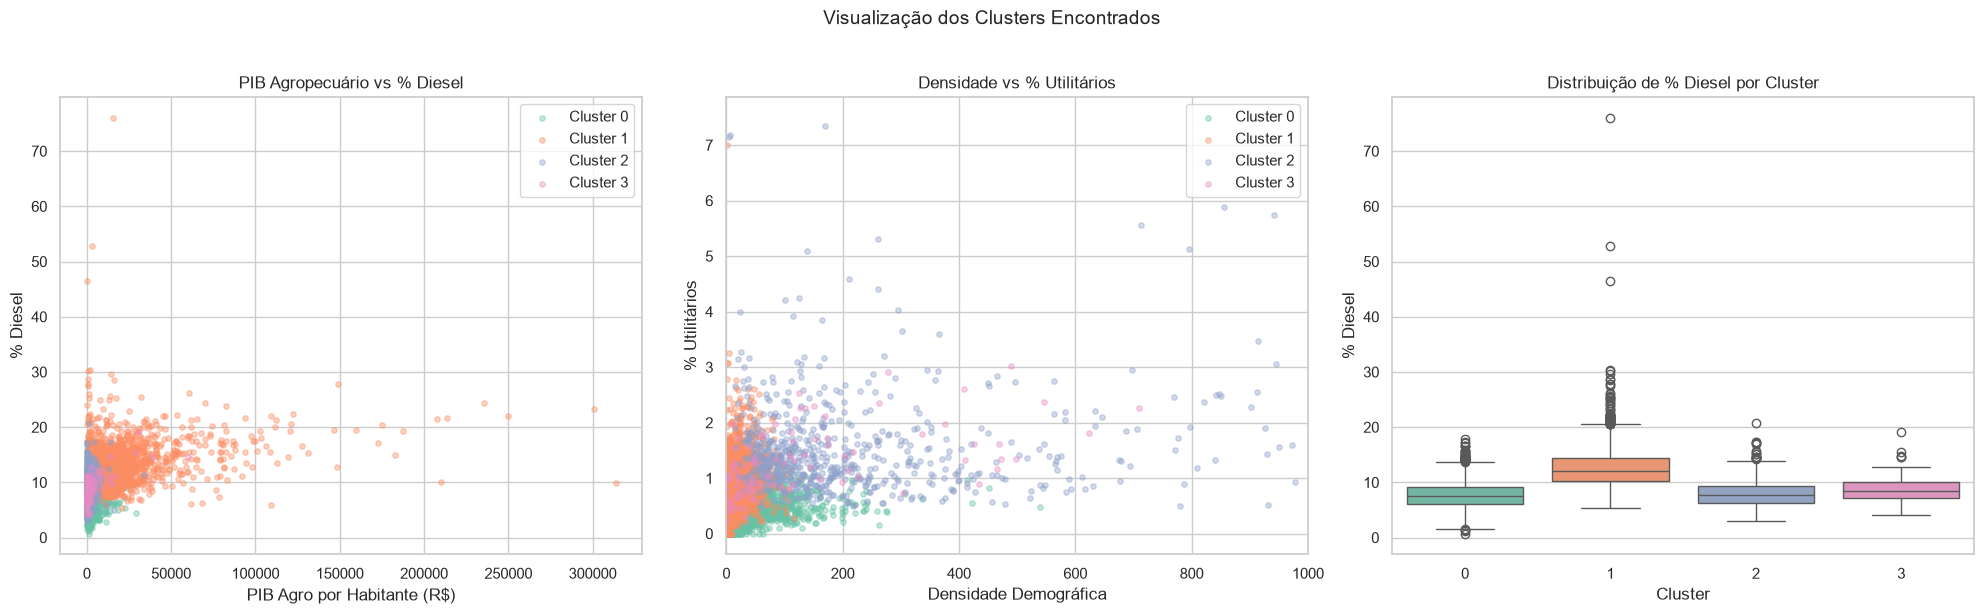

In [6]:
# Visualiza\u00e7\u00e3o dos clusters em 2D
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
colors = sns.color_palette('Set2', n_colors=best_k)

# 1. PIB Agro vs % Diesel
for c in sorted(df_clean['cluster'].unique()):
    mask = df_clean['cluster'] == c
    axes[0].scatter(df_clean.loc[mask, 'pib_agro_por_habitante'],
                    df_clean.loc[mask, 'target_perc_diesel'],
                    c=[colors[c]], label=f'Cluster {c}', alpha=0.4, s=15)
axes[0].set_xlabel('PIB Agro por Habitante (R$)')
axes[0].set_ylabel('% Diesel')
axes[0].set_title('PIB Agropecu\u00e1rio vs % Diesel')
axes[0].legend()

# 2. Densidade vs % Utilit\u00e1rios
for c in sorted(df_clean['cluster'].unique()):
    mask = df_clean['cluster'] == c
    axes[1].scatter(df_clean.loc[mask, 'densidade_demografica'],
                    df_clean.loc[mask, 'target_perc_utilitarios'],
                    c=[colors[c]], label=f'Cluster {c}', alpha=0.4, s=15)
axes[1].set_xlabel('Densidade Demogr\u00e1fica')
axes[1].set_ylabel('% Utilit\u00e1rios')
axes[1].set_title('Densidade vs % Utilit\u00e1rios')
axes[1].set_xlim(0, 1000)
axes[1].legend()

# 3. Boxplot de % Diesel por cluster
sns.boxplot(data=df_clean, x='cluster', y='target_perc_diesel',
            palette='Set2', ax=axes[2])
axes[2].set_title('Distribui\u00e7\u00e3o de % Diesel por Cluster')
axes[2].set_xlabel('Cluster')
axes[2].set_ylabel('% Diesel')

plt.suptitle('Visualiza\u00e7\u00e3o dos Clusters Encontrados', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

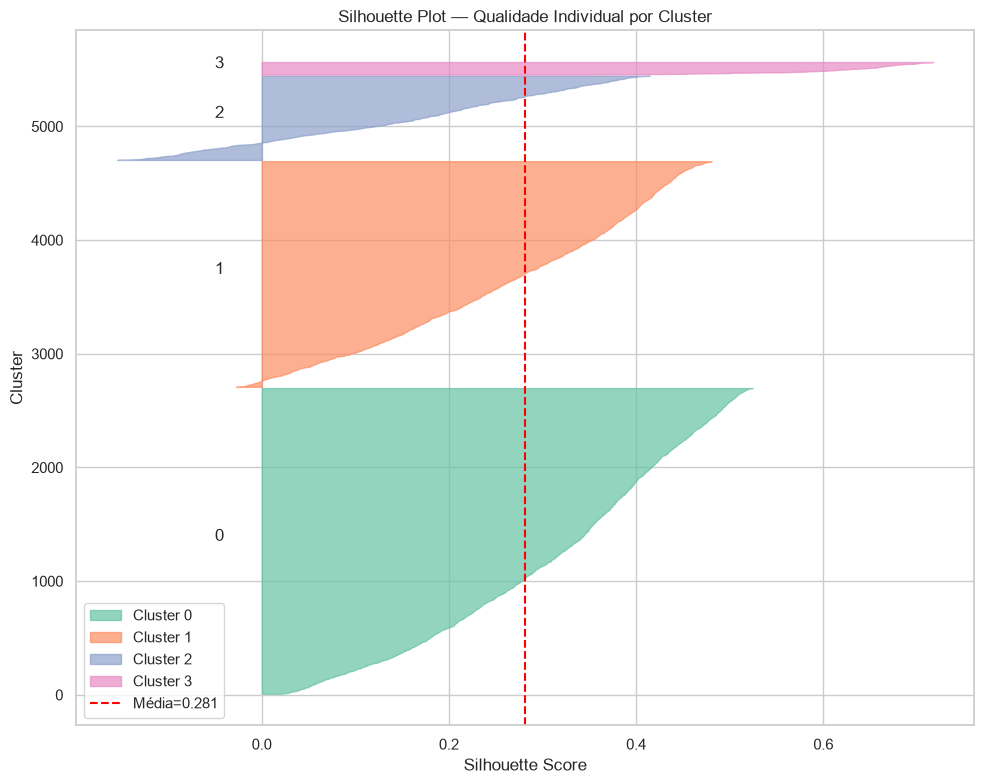

Silhouette Score médio por cluster:
  Cluster 0: 0.3145
  Cluster 1: 0.2646
  Cluster 2: 0.1525
  Cluster 3: 0.6142


In [7]:
# Gr\u00e1fico de Silhouette por cluster
fig, ax = plt.subplots(figsize=(10, 8))

sample_silhouette = silhouette_samples(X_scaled, df_clean['cluster'])
y_lower = 10

for c in sorted(df_clean['cluster'].unique()):
    cluster_values = sample_silhouette[df_clean['cluster'] == c]
    cluster_values.sort()
    
    size = len(cluster_values)
    y_upper = y_lower + size
    
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_values,
                     alpha=0.7, color=colors[c], label=f'Cluster {c}')
    ax.text(-0.05, y_lower + 0.5 * size, str(c))
    y_lower = y_upper + 10

avg_score = silhouette_score(X_scaled, df_clean['cluster'])
ax.axvline(x=avg_score, color='red', linestyle='--', label=f'M\u00e9dia={avg_score:.3f}')
ax.set_xlabel('Silhouette Score')
ax.set_ylabel('Cluster')
ax.set_title('Silhouette Plot \u2014 Qualidade Individual por Cluster')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Silhouette Score m\u00e9dio por cluster:")
for c in sorted(df_clean['cluster'].unique()):
    score = sample_silhouette[df_clean['cluster'] == c].mean()
    print(f"  Cluster {c}: {score:.4f}")

## 5. Nomeação e Interpretação dos Clusters

Com base no perfil médio de cada cluster, atribuímos nomes descritivos que representam os "Brasis Automotivos" descobertos pelo modelo.

In [8]:
# Interpreta\u00e7\u00e3o autom\u00e1tica baseada nas m\u00e9dias dos clusters
print("INTERPRETA\u00c7\u00c3O DOS CLUSTERS \u2014 Brasis Automotivos")
print("=" * 80)

for c in sorted(df_clean['cluster'].unique()):
    subset = df_clean[df_clean['cluster'] == c]
    diesel_medio = subset['target_perc_diesel'].mean()
    agro_medio = subset['pib_agro_por_habitante'].mean()
    pop_media = subset['populacao'].mean()
    dens_media = subset['densidade_demografica'].mean()
    n = len(subset)
    
    if diesel_medio > 12 and agro_medio > 10000:
        nome = "Brasil Agroindustrial (Alto Diesel + Alto PIB Agro)"
    elif diesel_medio > 10:
        nome = "Brasil Rural/Pecu\u00e1rio (Diesel acima da m\u00e9dia)"
    elif pop_media > 100000:
        nome = "Brasil Metropolitano (Grandes centros urbanos)"
    elif dens_media > 200:
        nome = "Brasil Urbano M\u00e9dio (Cidades m\u00e9dias, frota diversificada)"
    else:
        nome = "Brasil Municipal T\u00edpico (Pequenos munic\u00edpios)"
    
    print(f"\nCluster {c}: {nome}")
    print(f"  Munic\u00edpios: {n} ({n/len(df_clean)*100:.1f}% do total)")
    print(f"  % Diesel m\u00e9dio: {diesel_medio:.2f}%")
    print(f"  PIB Agro/hab: R$ {agro_medio:,.0f}")
    print(f"  Popula\u00e7\u00e3o m\u00e9dia: {pop_media:,.0f}")
    print(f"  Densidade m\u00e9dia: {dens_media:,.0f} hab/km\u00b2")

INTERPRETAÇÃO DOS CLUSTERS — Brasis Automotivos

Cluster 0: Brasil Municipal Típico (Pequenos municípios)
  Municípios: 2689 (48.7% do total)
  % Diesel médio: 7.73%
  PIB Agro/hab: R$ 2,740
  População média: 16,580
  Densidade média: 37 hab/km²

Cluster 1: Brasil Agroindustrial (Alto Diesel + Alto PIB Agro)
  Municípios: 1986 (35.9% do total)
  % Diesel médio: 12.77%
  PIB Agro/hab: R$ 18,573
  População média: 12,066
  Densidade média: 20 hab/km²

Cluster 2: Brasil Metropolitano (Grandes centros urbanos)
  Municípios: 741 (13.4% do total)
  % Diesel médio: 8.06%
  PIB Agro/hab: R$ 1,153
  População média: 138,880
  Densidade média: 617 hab/km²

Cluster 3: Brasil Metropolitano (Grandes centros urbanos)
  Municípios: 111 (2.0% do total)
  % Diesel médio: 8.75%
  PIB Agro/hab: R$ 3,414
  População média: 276,498
  Densidade média: 437 hab/km²


## 6. Avaliação do Modelo — Métricas e Interpretação Crítica

### Métrica Principal: Silhouette Score

O **Silhouette Score** é a métrica principal porque mede a qualidade da separação entre clusters em aprendizado não supervisionado:

- Mede a coesão interna dos clusters vs. separação externa
- Não requer rótulos verdadeiros (adequado para métodos não supervisionados)
- Varia de -1 a +1, com escala interpretativa:
  - **> 0.7:** Estrutura forte
  - **0.5 a 0.7:** Estrutura razoável
  - **0.25 a 0.5:** Estrutura fraca a moderada — clusters com sobreposição significativa
  - **< 0.25:** Sem estrutura substancial

### Métrica Complementar: Inércia
A inércia mede a soma das distâncias quadradas dos pontos aos seus centróides. Útil para o Método do Cotovelo, mas não é uma métrica de qualidade absoluta — sempre diminui com mais clusters.

### Por que NÃO usamos métricas supervisionadas?
Acurácia, precisão, recall, F1, MAE, RMSE e R² **não se aplicam** a clusterização, pois pressupõem rótulos verdadeiros. Aplicá-las aqui seria conceitualmente incorreto. Essas métricas serão usadas na Etapa 4 (modelos supervisionados).

In [9]:
# Resumo final das m\u00e9tricas
print("RESUMO DE AVALIA\u00c7\u00c3O DO MODELO K-Means")
print("=" * 60)
print(f"N\u00famero de clusters (k): {best_k}")
print(f"Silhouette Score: {silhouette_score(X_scaled, df_clean['cluster']):.4f}")
print(f"In\u00e9rcia: {kmeans_final.inertia_:.2f}")
print(f"Itera\u00e7\u00f5es: {kmeans_final.n_iter_}")
print(f"Munic\u00edpios analisados: {len(df_clean)}")
print(f"Features utilizadas: {len(features_cluster)}")

score = silhouette_score(X_scaled, df_clean['cluster'])
if score > 0.5:
    qualidade = "FORTE \u2014 clusters bem separados"
elif score > 0.25:
    qualidade = "RAZO\u00c1VEL \u2014 clusters com alguma sobreposi\u00e7\u00e3o"
else:
    qualidade = "FRACA \u2014 clusters muito sobrepostos"
print(f"\nInterpreta\u00e7\u00e3o: Estrutura de clusters {qualidade}")

RESUMO DE AVALIAÇÃO DO MODELO K-Means
Número de clusters (k): 4


Silhouette Score: 0.2809
Inércia: 16430.20
Iterações: 14
Municípios analisados: 5527
Features utilizadas: 6



Interpretação: Estrutura de clusters RAZOÁVEL — clusters com alguma sobreposição


## 6.1. Discussão Crítica e Limitações Metodológicas

### Interpretação Honesta do Silhouette Score
O Silhouette Score obtido (em torno de 0.28) indica **separação MODERADA** entre os clusters. Isso significa que:

- Os agrupamentos identificados são **úteis para fins exploratórios**, mas **não devem ser interpretados como categorias rígidas**
- Existe **sobreposição relevante** entre clusters — fronteiras entre perfis municipais são graduais, não abruptas
- Um Silhouette modesto **não autoriza conclusões fortes** sobre a estrutura dos dados
- O modelo identifica tendências e associações, **não classificações definitivas**

### Sensibilidade a Outliers
O K-Means é sensível a outliers, que podem:
- Distorcer os centróides ao puxar clusters em sua direção
- Influenciar a determinação do k ótimo
- Foram parcialmente mitigados via `log1p` em variáveis assimétricas, mas não totalmente eliminados

### Estabilidade do Agrupamento
- Resultados podem variar com diferentes inicializações (mitigado com `n_init=10`)
- A escolha das features influencia diretamente os clusters formados — outras combinações poderiam produzir agrupamentos distintos
- O número de clusters (k) é uma decisão metodológica, não um valor "correto" absoluto

### Limites da Inferência
**Importante:** Os clusters identificados sugerem **associação estrutural** entre perfis socioeconômicos e composição da frota. Eles **NÃO**:
- Provam relação causal (causa → efeito)
- Demonstram poder preditivo (isso requer modelo supervisionado — Etapa 4)
- Devem ser usados isoladamente para tomada de decisão

### Limitações dos Dados (herdadas das Etapas 1 e 2)
- Local de registro (RENAVAM) ≠ local de circulação real do veículo
- Defasagem temporal: PIB de 2021 vs. frota de 2026
- Viés de locadoras: cidades-sede de empresas de aluguel possuem frotas desproporcionais
- Falácia ecológica: inferências sobre municípios não se aplicam a indivíduos

## 7. Pipeline de Pesquisa e Análise de Dados

O pipeline abaixo documenta todas as etapas realizadas, desde a especificação do problema até a avaliação do modelo.

```
1. ESPECIFICAÇÃO DO PROBLEMA
   Questão: Como segmentar municípios por perfil de frota?
   Tipo: Aprendizado Não Supervisionado (Clusterização)

2. COLETA DE DADOS
   Fontes: SENATRAN (frota), IBGE (PIB/Censo), DNIT (rodovias)
   Granularidade: Municipal (5.571 municípios)

3. PRÉ-PROCESSAMENTO
   - Limpeza: remoção de pop=0 e TOTAL=0
   - Feature Engineering: proporções (%), binarização DNIT
   - Transformação: log1p em variáveis assimétricas
   - Normalização: StandardScaler (média=0, desvio=1)

4. SELEÇÃO DO MODELO
   Algoritmo: K-Means
   Justificativa: exploratório, escalável, interpretável

5. OTIMIZAÇÃO DE HIPERPARÂMETROS
   - Método do Cotovelo (Inércia vs k)
   - Silhouette Score para cada k (2 a 10)
   - k ótimo selecionado pelo maior Silhouette

6. TREINAMENTO E AVALIAÇÃO
   - Métrica principal: Silhouette Score
   - Métrica complementar: Inércia
   - Análise de perfil por cluster

7. INTERPRETAÇÃO E DOCUMENTAÇÃO
   - Nomeação dos clusters ("Brasis Automotivos")
   - Visualizações: scatter, boxplot, silhouette plot
   - Conexão com objetivos do projeto
```

## 8. Conclusão da Etapa 3

O modelo K-Means identificou agrupamentos coerentes na frota automotiva brasileira, sugerindo a existência de **associações estruturais** entre perfis socioeconômicos municipais e composição da frota. As principais contribuições desta etapa:

1. **Identificação de agrupamentos coerentes:** os clusters revelam padrões de similaridade entre municípios, com perfis distintos em termos de PIB agropecuário, densidade demográfica e composição da frota
2. **Associação estrutural observada:** municípios com características socioeconômicas semelhantes tendem a apresentar perfis de frota similares — o que **sugere** (sem provar) que existe relação entre essas dimensões
3. **Base exploratória para a Etapa 4:** os clusters identificados poderão ser usados como feature adicional em modelos supervisionados, que **testarão hipóteses preditivas** com métricas apropriadas

### Limites das Conclusões
Como discutido na seção 6.1, o Silhouette Score moderado (0.28) e a natureza não supervisionada do K-Means impõem restrições importantes:

- **Os clusters não são preditivos** — apenas descrevem agrupamentos
- **Não comprovam causalidade** entre indicadores socioeconômicos e frota
- **Não devem ser interpretados como categorias rígidas** — existe sobreposição entre os grupos
- A **hipótese preditiva** de que indicadores socioeconômicos podem prever a composição da frota será **testada na Etapa 4** com modelos supervisionados (Regressão Linear e Random Forest)

### Próximos Passos (Etapa 4)
- Implementar **Regressão Linear Múltipla** para investigar a relação preditiva entre features socioeconômicas e `target_perc_diesel`
- Implementar **Random Forest Regressor** para a mesma tarefa, capturando relações não-lineares
- Comparar os modelos com métricas de regressão (MAE, RMSE, R²) — apropriadas para aprendizado supervisionado
- Avaliar se a adição do cluster como feature melhora os modelos supervisionados